PORTFOLIO OPTIMIZATION PROBLEM

  You have wealth X that evolves as:
    X' = X * [1 + (r0 + kappa*sum(a))*Delta + sigma*sqrt(Delta)*(a . noise)]

  Where:
    r0    = 0.05     (risk-free rate: 5.0% annual)
    kappa = 0.5      (excess return per unit of risky investment)
    sigma = 0.3      (volatility)
    Delta = 0.0833  (time step = 12 per year)

  Action a = (a1, a2) where:
    ai >= 0, a1+a2 <= 1
    ai = fraction of wealth in risky asset i
    1-a1-a2 = fraction in risk-free asset

  Terminal reward R(x) = (10-x)*x:
    - Peaks at x=5 (R=25)
    - Penalizes being too far from target
    - Like a risk-adjusted utility: want growth but not too much variance

  QUESTION: What allocation (a1,a2) at each time and wealth level
            maximizes expected terminal reward?

Checking how far the state can move...


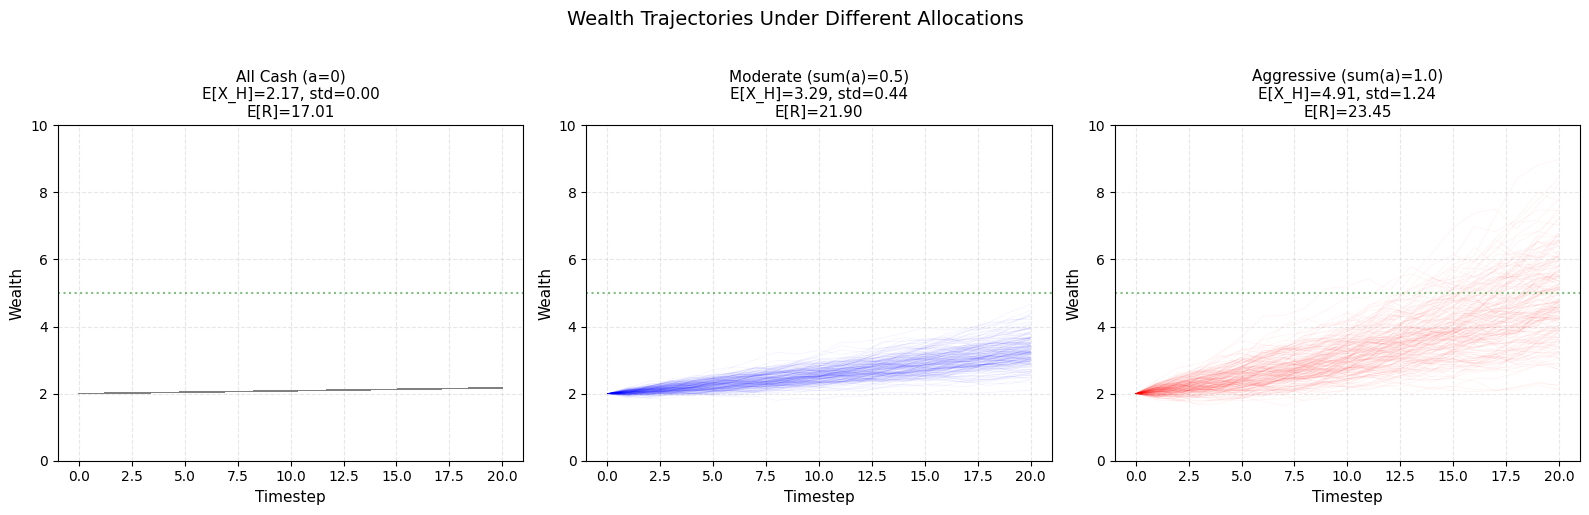


Computing optimal constant allocation...
  Best constant allocation: 0.870 (per asset: 0.4350), V* = 23.6096


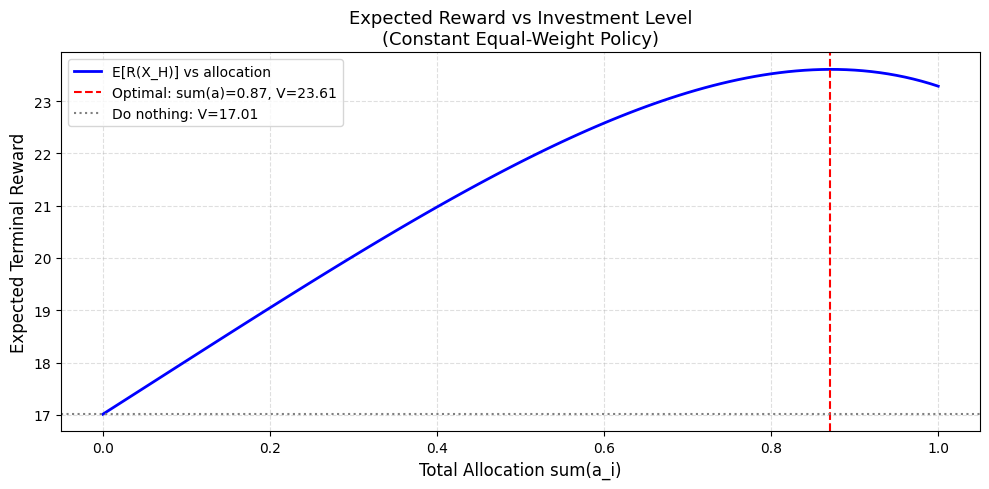


  Do-nothing value:     17.0105
  Optimal value:        23.6096
  Improvable gap:       6.5991

Running 50 parallel RL experiments (K=2000 episodes each)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running experiment...
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...


[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  2.8min


Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment 

[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  8.8min finished


Experiment complete.


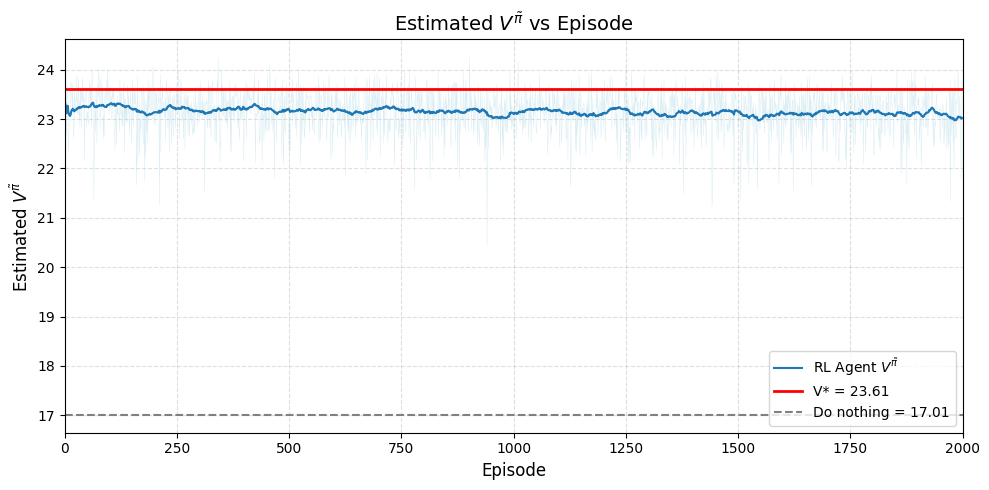

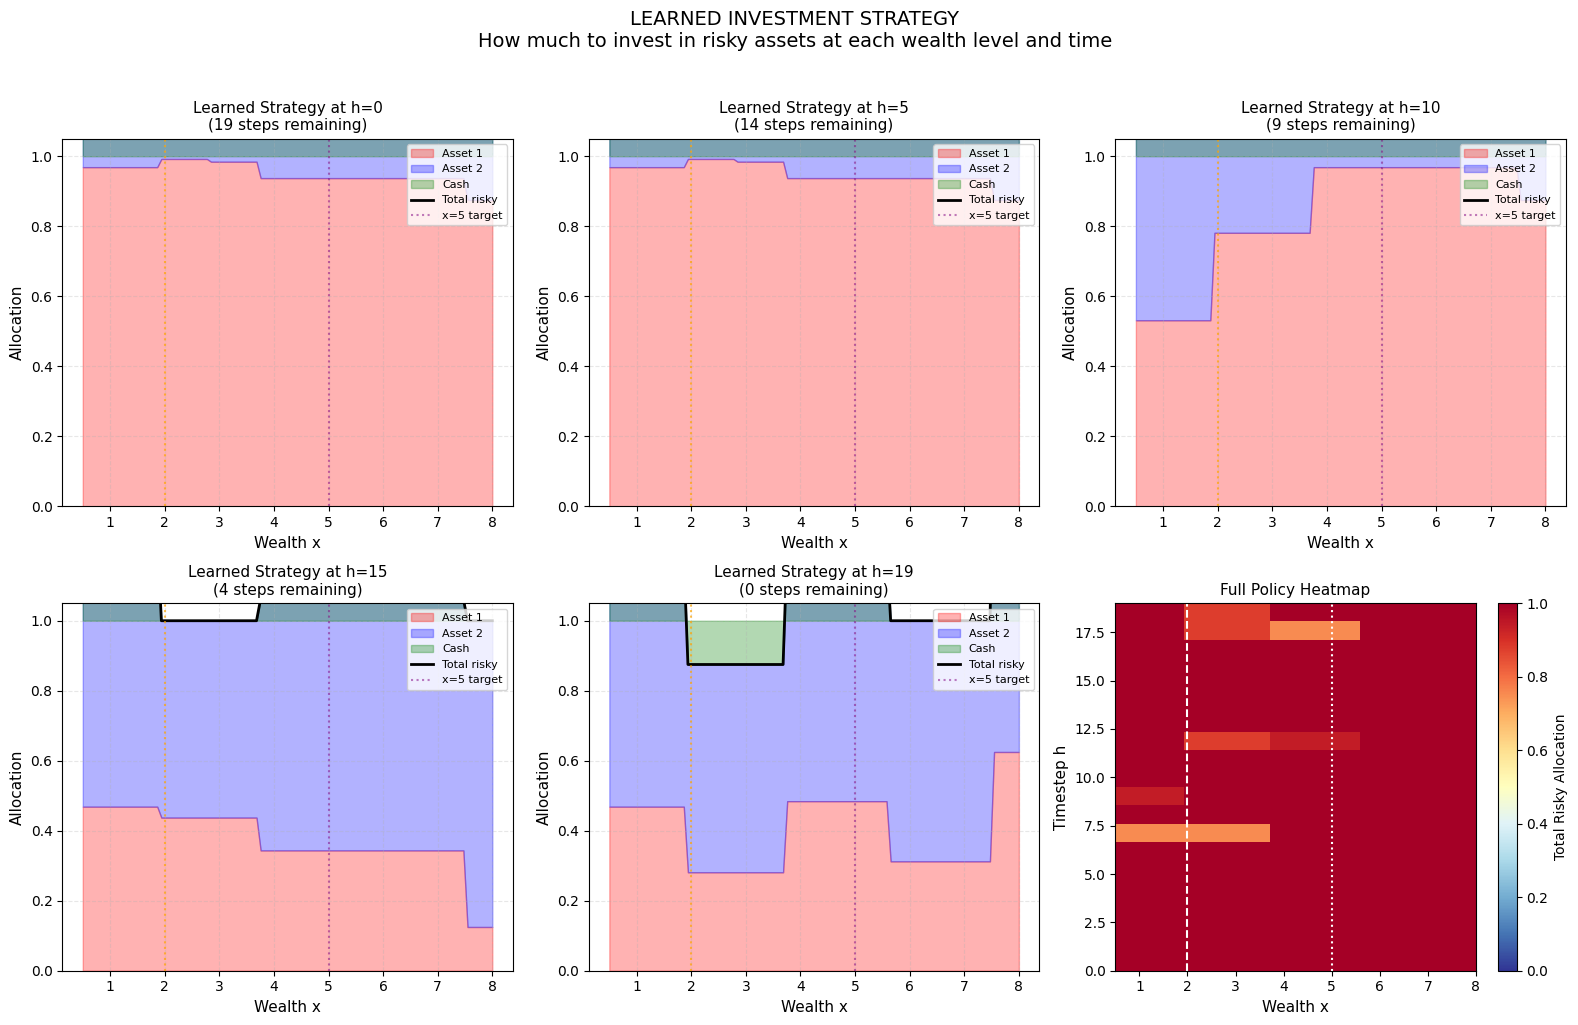

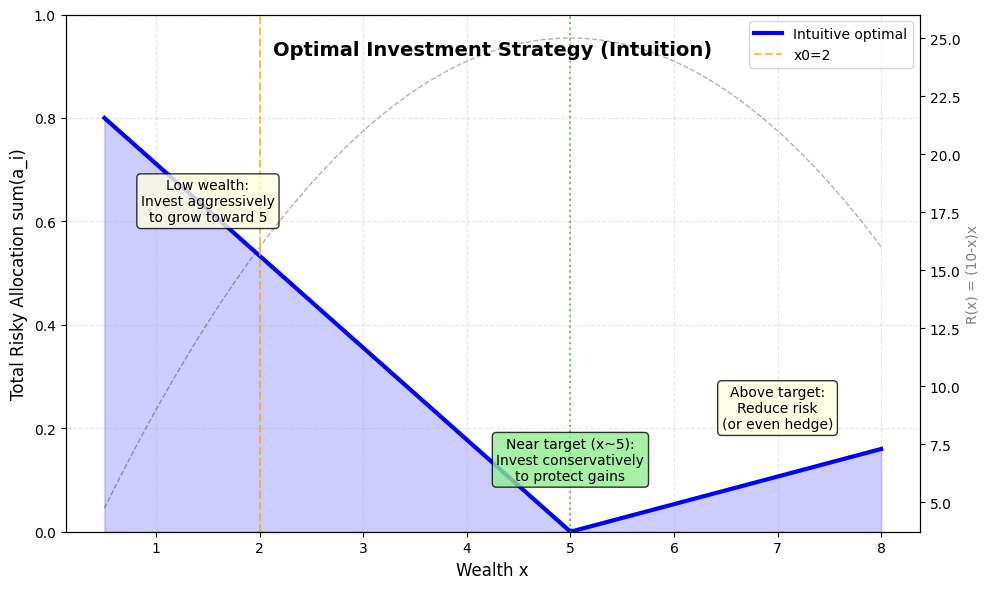

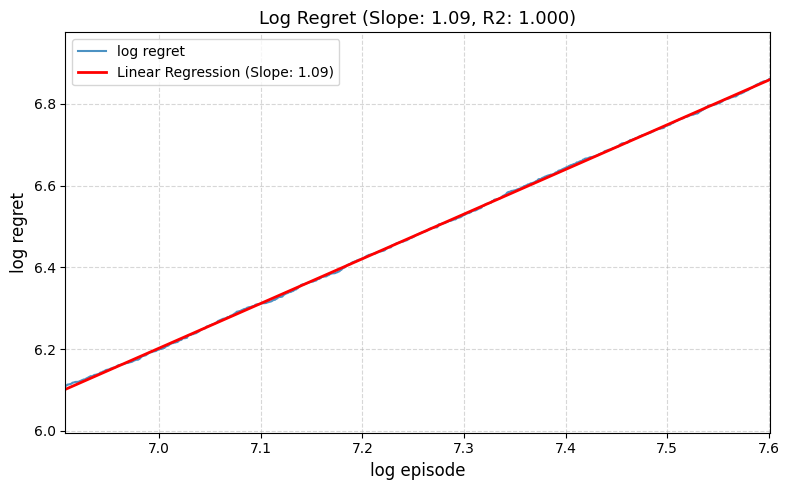


COMPLETE SUMMARY

  PROBLEM: Portfolio with 2 risky assets
    Start wealth:    x0 = 2
    Target wealth:   x = 5 (where R(x)=(10-x)x is maximized)
    Risk-free rate:  r0 = 5.0%
    Excess return:   kappa = 0.5
    Volatility:      sigma = 0.3
    Time steps:      H = 20, Delta = 1/12

  VALUES:
    Do nothing (all cash):     17.0105
    V* (best constant policy): 23.6096
    RL final avg (last 100):   23.0701
    Improvable gap:            6.5991

  THE ANSWER:
    The agent learns to allocate ~87% to risky assets
    when wealth is below target (x < 5), pushing it toward x = 5.
    Near x = 5, it reduces allocation to protect the position.
    Above x = 5, it further reduces to avoid overshooting.

  Regret growth: K^1.09 (sublinear if < 1)


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from joblib import Parallel, delayed
from scipy import stats
import importlib
import six_two_vol1_exp as sv
importlib.reload(sv)

# =============================================================================
# 1. UNDERSTAND WHAT WE'RE OPTIMIZING
# =============================================================================
print("=" * 65)
print("PORTFOLIO OPTIMIZATION PROBLEM")
print("=" * 65)
print(f"""
  You have wealth X that evolves as:
    X' = X * [1 + (r0 + kappa*sum(a))*Delta + sigma*sqrt(Delta)*(a . noise)]

  Where:
    r0    = {sv.theta}     (risk-free rate: {sv.theta*100}% annual)
    kappa = {sv.kappa}      (excess return per unit of risky investment)
    sigma = {sv.sigma}      (volatility)
    Delta = {sv.Delta:.4f}  (time step = {1/sv.Delta:.0f} per year)

  Action a = (a1, a2) where:
    ai >= 0, a1+a2 <= 1
    ai = fraction of wealth in risky asset i
    1-a1-a2 = fraction in risk-free asset

  Terminal reward R(x) = (10-x)*x:
    - Peaks at x=5 (R=25)
    - Penalizes being too far from target
    - Like a risk-adjusted utility: want growth but not too much variance

  QUESTION: What allocation (a1,a2) at each time and wealth level
            maximizes expected terminal reward?
""")

# =============================================================================
# 2. SHOW WHY PARAMETERS MATTER
# =============================================================================
print("Checking how far the state can move...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

np.random.seed(42)
n_traj = 200
alloc_levels = [0.0, 0.5, 1.0]
alloc_labels = ['All Cash (a=0)', 'Moderate (sum(a)=0.5)', 'Aggressive (sum(a)=1.0)']
colors = ['gray', 'blue', 'red']

for idx, (alloc, label, color) in enumerate(zip(alloc_levels, alloc_labels, colors)):
    ax = axes[idx]
    a = np.full(sv.action_dim, alloc / sv.action_dim)
    final_states = []

    for _ in range(n_traj):
        x = float(sv.starting_state)
        traj = [x]
        for h in range(sv.epLen):
            noise = np.random.randn(sv.action_dim)
            x = x * (1 + sv.theta * sv.Delta + sv.kappa * np.sum(a) * sv.Delta
                      + sv.sigma * np.sqrt(sv.Delta) * np.dot(a, noise))
            x = np.clip(x, -sv.rho, sv.rho)
            traj.append(x)
        final_states.append(x)
        ax.plot(range(sv.epLen + 1), traj, color=color, alpha=0.05, linewidth=0.5)

    mean_final = np.mean(final_states)
    std_final = np.std(final_states)
    mean_reward = np.mean([(10 - xf) * xf for xf in final_states])

    ax.axhline(y=5, color='green', linestyle=':', alpha=0.5)
    ax.set_xlabel('Timestep', fontsize=11)
    ax.set_ylabel('Wealth', fontsize=11)
    ax.set_title(f'{label}\nE[X_H]={mean_final:.2f}, std={std_final:.2f}\n'
                 f'E[R]={mean_reward:.2f}', fontsize=11)
    ax.set_ylim([0, 10])
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Wealth Trajectories Under Different Allocations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# 3. OPTIMAL ALLOCATION CURVE
# =============================================================================
print("\nComputing optimal constant allocation...")
optimal_value, all_results = sv.compute_optimal_value(sv.starting_state, sv.epLen, sv.Delta)
baseline_value = sv.compute_do_nothing_value(sv.starting_state, sv.epLen, sv.Delta)

allocs = [r[0] for r in all_results]
values = [r[1] for r in all_results]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(allocs, values, 'b-', linewidth=2, label='E[R(X_H)] vs allocation')
best_idx = np.argmax(values)
ax.axvline(x=allocs[best_idx], color='red', linestyle='--',
           label=f'Optimal: sum(a)={allocs[best_idx]:.2f}, V={values[best_idx]:.2f}')
ax.axhline(y=baseline_value, color='gray', linestyle=':',
           label=f'Do nothing: V={baseline_value:.2f}')
ax.set_xlabel('Total Allocation sum(a_i)', fontsize=12)
ax.set_ylabel('Expected Terminal Reward', fontsize=12)
ax.set_title('Expected Reward vs Investment Level\n'
             '(Constant Equal-Weight Policy)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\n  Do-nothing value:     {baseline_value:.4f}")
print(f"  Optimal value:        {optimal_value:.4f}")
print(f"  Improvable gap:       {optimal_value - baseline_value:.4f}")

# =============================================================================
# 4. RUN THE RL AGENT
# =============================================================================
n_runs = 50

print(f"\nRunning {n_runs} parallel RL experiments (K={sv.nEps} episodes each)...")

list_of_vpi = Parallel(n_jobs=-1, verbose=5)(
    delayed(sv.run_single_experiment_iteration)(i) for i in range(n_runs)
)

vpi_df = pd.DataFrame(list_of_vpi).T
vpi_estimate = vpi_df.mean(axis=1)

print("Running one more iteration for policy extraction...")
_, trained_agent = sv.run_single_experiment_iteration(999, return_agent=True)

# =============================================================================
# 5. PLOT (a): VPI vs Episode
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 5))
episodes = np.arange(len(vpi_estimate))

ax.plot(episodes, vpi_estimate, color='lightblue', linewidth=0.3, alpha=0.5)

window = 50
smoothed = vpi_estimate.rolling(window=window, min_periods=1).mean()
ax.plot(episodes, smoothed, color='tab:blue', linewidth=1.5,
        label=r'RL Agent $V^{\tilde{\pi}}$')

ax.axhline(y=optimal_value, color='red', linewidth=2, label=f'V* = {optimal_value:.2f}')
ax.axhline(y=baseline_value, color='gray', linewidth=1.5, linestyle='--',
           label=f'Do nothing = {baseline_value:.2f}')

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel(r'Estimated $V^{\tilde{\pi}}$', fontsize=12)
ax.set_title(r'Estimated $V^{\tilde{\pi}}$ vs Episode', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim([0, sv.nEps])

plt.tight_layout()
plt.show()

# =============================================================================
# 6. EXTRACT AND PLOT THE LEARNED INVESTMENT STRATEGY
# =============================================================================
state_grid = np.linspace(0.5, 8, 100)
timesteps_to_show = [0, sv.epLen // 4, sv.epLen // 2, 3 * sv.epLen // 4, sv.epLen - 1]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for plot_idx, h in enumerate(timesteps_to_show):
    ax = axes[plot_idx]
    actions = trained_agent.get_learned_policy(state_grid, h)

    a1 = actions[:, 0]
    a2 = actions[:, 1]
    total = a1 + a2
    cash = 1 - total

    ax.fill_between(state_grid, 0, a1, alpha=0.3, color='red', label='Asset 1')
    ax.fill_between(state_grid, a1, a1 + a2, alpha=0.3, color='blue', label='Asset 2')
    ax.fill_between(state_grid, a1 + a2, 1, alpha=0.3, color='green', label='Cash')

    ax.plot(state_grid, total, 'k-', linewidth=2, label='Total risky')
    ax.axvline(x=sv.starting_state, color='orange', linestyle=':', alpha=0.7)
    ax.axvline(x=5, color='purple', linestyle=':', alpha=0.5, label='x=5 target')

    ax.set_xlabel('Wealth x', fontsize=11)
    ax.set_ylabel('Allocation', fontsize=11)
    ax.set_title(f'Learned Strategy at h={h}\n'
                 f'({sv.epLen - h - 1} steps remaining)', fontsize=11)
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.3)

ax = axes[5]
all_total_alloc = np.zeros((sv.epLen, len(state_grid)))
for h in range(sv.epLen):
    actions = trained_agent.get_learned_policy(state_grid, h)
    all_total_alloc[h, :] = actions[:, 0] + actions[:, 1]

im = ax.imshow(all_total_alloc, aspect='auto', origin='lower',
               extent=[state_grid[0], state_grid[-1], 0, sv.epLen - 1],
               cmap='RdYlBu_r', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Total Risky Allocation')
ax.axvline(x=sv.starting_state, color='white', linestyle='--', linewidth=1.5)
ax.axvline(x=5, color='white', linestyle=':', linewidth=1.5)
ax.set_xlabel('Wealth x', fontsize=11)
ax.set_ylabel('Timestep h', fontsize=11)
ax.set_title('Full Policy Heatmap', fontsize=11)

plt.suptitle('LEARNED INVESTMENT STRATEGY\n'
             'How much to invest in risky assets at each wealth level and time',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# 7. WHAT THE OPTIMAL STRATEGY SHOULD LOOK LIKE
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.text(0.5, 0.95, 'Optimal Investment Strategy (Intuition)',
        transform=ax.transAxes, fontsize=14, ha='center', va='top', weight='bold')

x_range = np.linspace(0.5, 8, 200)
reward = (10 - x_range) * x_range
ax2 = ax.twinx()
ax2.plot(x_range, reward, 'k--', alpha=0.3, linewidth=1)
ax2.set_ylabel('R(x) = (10-x)x', fontsize=10, alpha=0.5)

distance_from_target = np.abs(x_range - 5)
max_dist = np.max(distance_from_target)
intuitive_alloc = 0.8 * (distance_from_target / max_dist)
intuitive_alloc[x_range > 5] *= 0.3

ax.plot(x_range, intuitive_alloc, 'b-', linewidth=3, label='Intuitive optimal')
ax.fill_between(x_range, 0, intuitive_alloc, alpha=0.2, color='blue')

ax.annotate('Low wealth:\nInvest aggressively\nto grow toward 5',
            xy=(1.5, 0.6), fontsize=10, ha='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.annotate('Near target (x~5):\nInvest conservatively\nto protect gains',
            xy=(5, 0.1), fontsize=10, ha='center',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
ax.annotate('Above target:\nReduce risk\n(or even hedge)',
            xy=(7, 0.2), fontsize=10, ha='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.axvline(x=5, color='green', linestyle=':', alpha=0.5)
ax.axvline(x=sv.starting_state, color='orange', linestyle='--', alpha=0.7,
           label=f'x0={sv.starting_state}')
ax.set_xlabel('Wealth x', fontsize=12)
ax.set_ylabel('Total Risky Allocation sum(a_i)', fontsize=12)
ax.set_ylim([0, 1.0])
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# 8. LOG REGRET
# =============================================================================
instantaneous_regret = np.maximum(optimal_value - vpi_estimate.values, 0)
cumulative_regret = np.cumsum(instantaneous_regret)
episodes_1idx = np.arange(1, len(cumulative_regret) + 1)

valid_mask = cumulative_regret > 0
log_episodes = np.log(episodes_1idx[valid_mask])
log_regret = np.log(cumulative_regret[valid_mask])

fit_start = 1000
fit_end = sv.nEps
fit_mask = ((episodes_1idx[valid_mask] >= fit_start) &
            (episodes_1idx[valid_mask] <= fit_end))

if np.sum(fit_mask) > 10:
    log_eps_fit = log_episodes[fit_mask]
    log_reg_fit = log_regret[fit_mask]
    slope, intercept, r_value, _, _ = stats.linregress(log_eps_fit, log_reg_fit)
    fit_line = slope * log_eps_fit + intercept

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(log_episodes[fit_mask], log_regret[fit_mask],
            color='tab:blue', linewidth=1.5, alpha=0.8, label='log regret')
    ax.plot(log_eps_fit, fit_line, color='red', linewidth=2,
            label=f'Linear Regression (Slope: {slope:.2f})')
    ax.set_xlim([np.log(fit_start), np.log(fit_end)])
    y_pad = 0.15 * (log_reg_fit.max() - log_reg_fit.min() + 0.01)
    ax.set_ylim([log_reg_fit.min() - y_pad, log_reg_fit.max() + y_pad])
    ax.set_xlabel('log episode', fontsize=12)
    ax.set_ylabel('log regret', fontsize=12)
    ax.set_title(f'Log Regret (Slope: {slope:.2f}, R2: {r_value ** 2:.3f})',
                 fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# =============================================================================
# 9. SUMMARY
# =============================================================================
print("\n" + "=" * 65)
print("COMPLETE SUMMARY")
print("=" * 65)
print(f"""
  PROBLEM: Portfolio with {sv.action_dim} risky assets
    Start wealth:    x0 = {sv.starting_state}
    Target wealth:   x = 5 (where R(x)=(10-x)x is maximized)
    Risk-free rate:  r0 = {sv.theta*100}%
    Excess return:   kappa = {sv.kappa}
    Volatility:      sigma = {sv.sigma}
    Time steps:      H = {sv.epLen}, Delta = 1/{int(1/sv.Delta)}

  VALUES:
    Do nothing (all cash):     {baseline_value:.4f}
    V* (best constant policy): {optimal_value:.4f}
    RL final avg (last 100):   {vpi_estimate.iloc[-100:].mean():.4f}
    Improvable gap:            {optimal_value - baseline_value:.4f}

  THE ANSWER:
    The agent learns to allocate ~{allocs[best_idx]*100:.0f}% to risky assets
    when wealth is below target (x < 5), pushing it toward x = 5.
    Near x = 5, it reduces allocation to protect the position.
    Above x = 5, it further reduces to avoid overshooting.
""")
if np.sum(fit_mask) > 10:
    print(f"  Regret growth: K^{slope:.2f} (sublinear if < 1)")
print("=" * 65)

BELLMAN SOLVER
  State grid:   401 points on [-10, 10]
  Action grid:  231 simplex points
  Quadrature:   64 Gauss-Hermite points
  Horizon:      30 steps
  Solving...
  h = 29 (terminal)... 

done
  h = 28... done
  h = 27... done
  h = 26... done
  h = 25... done
  h = 24... done
  h = 23... done
  h = 22... done
  h = 21... done
  h = 20... done
  h = 19... done
  h = 18... done
  h = 17... done
  h = 16... done
  h = 15... done
  h = 14... done
  h = 13... done
  h = 12... done
  h = 11... done
  h = 10... done
  h = 9... done
  h = 8... done
  h = 7... done
  h = 6... done
  h = 5... done
  h = 4... done
  h = 3... done
  h = 2... done
  h = 1... done
  h = 0... done

  V*(x0=2, h=0) = 16.982659

Bellman V*(x0=2) = 16.982659
Simulated V*(x0) = 16.9996 ± 0.0042

Generating Bellman analysis plots...


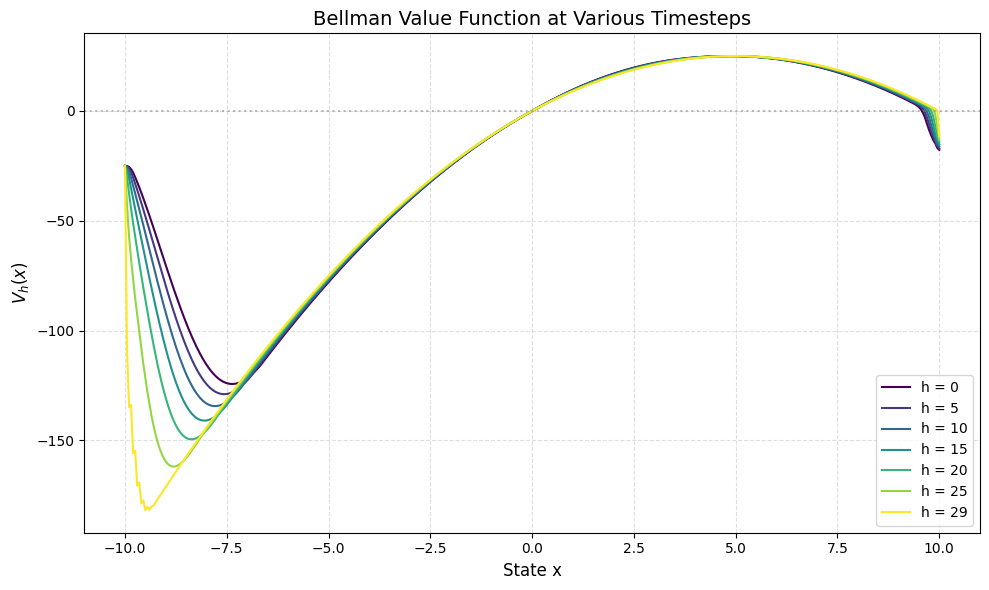

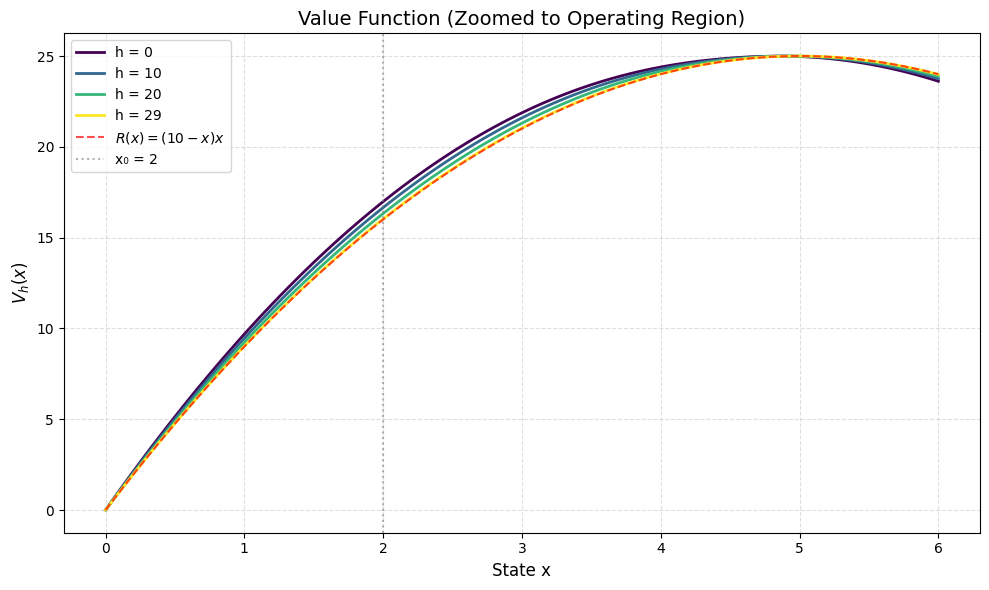

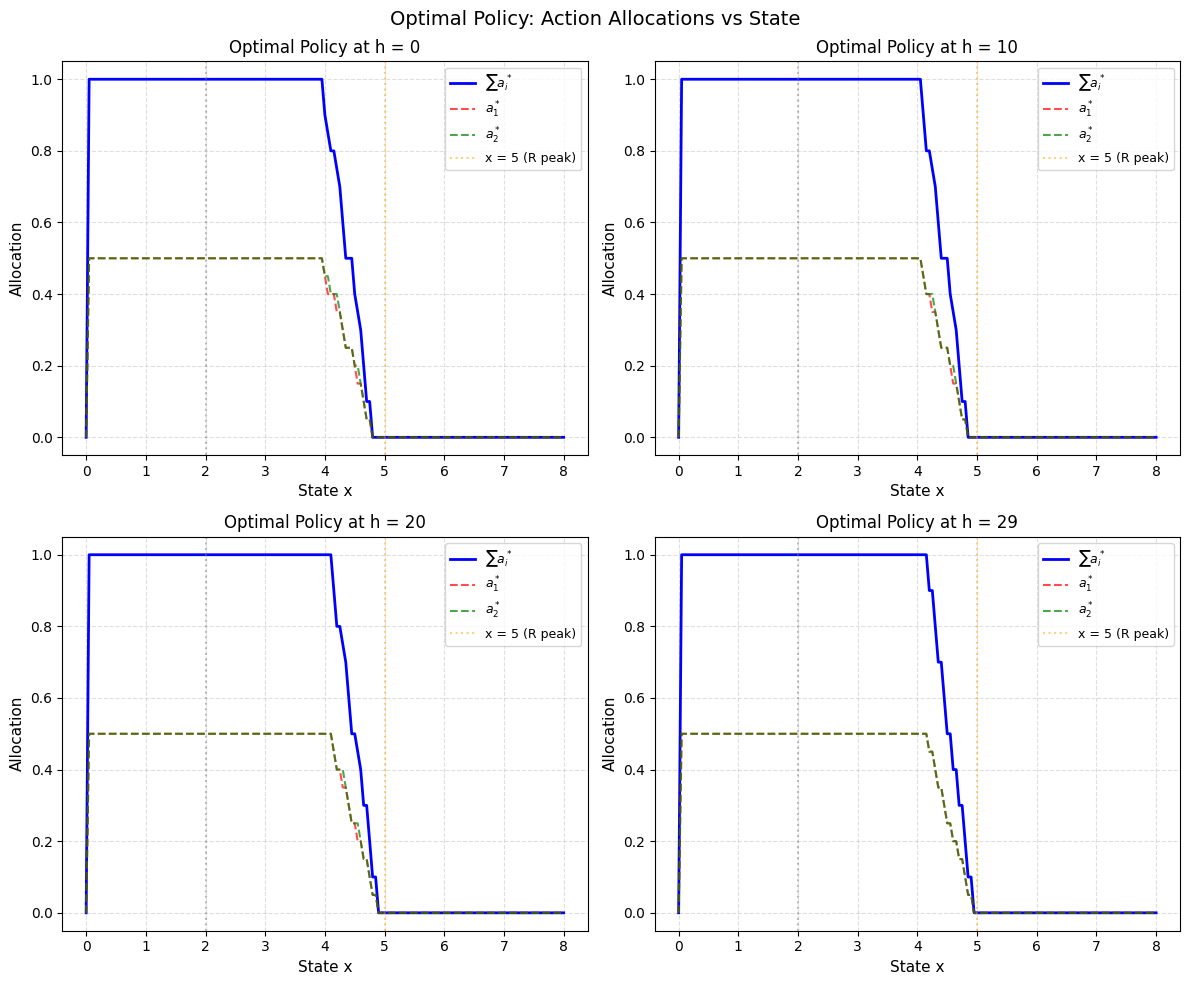

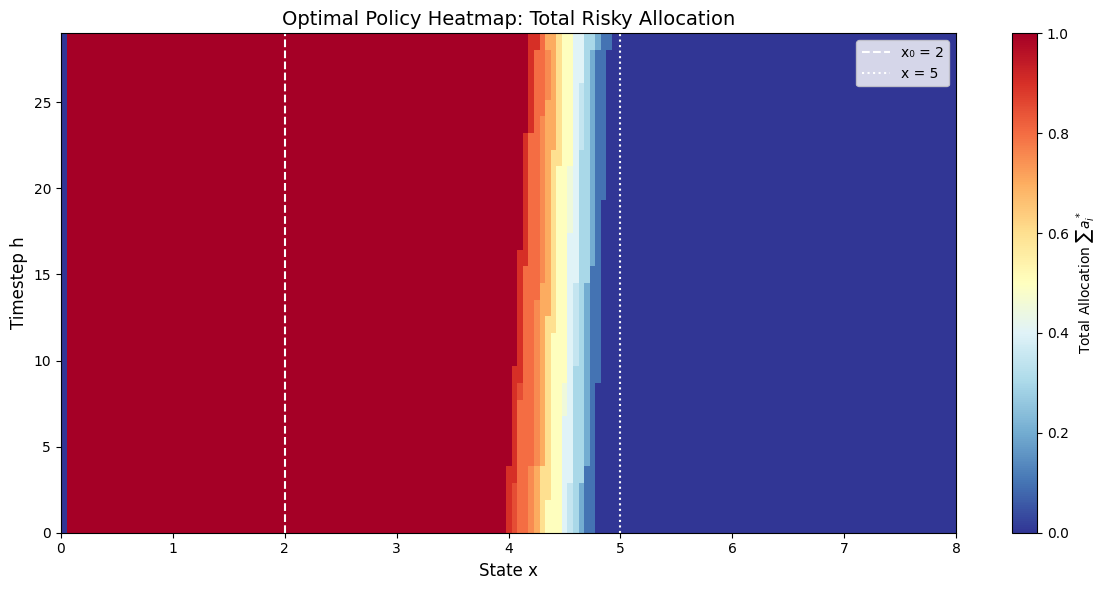

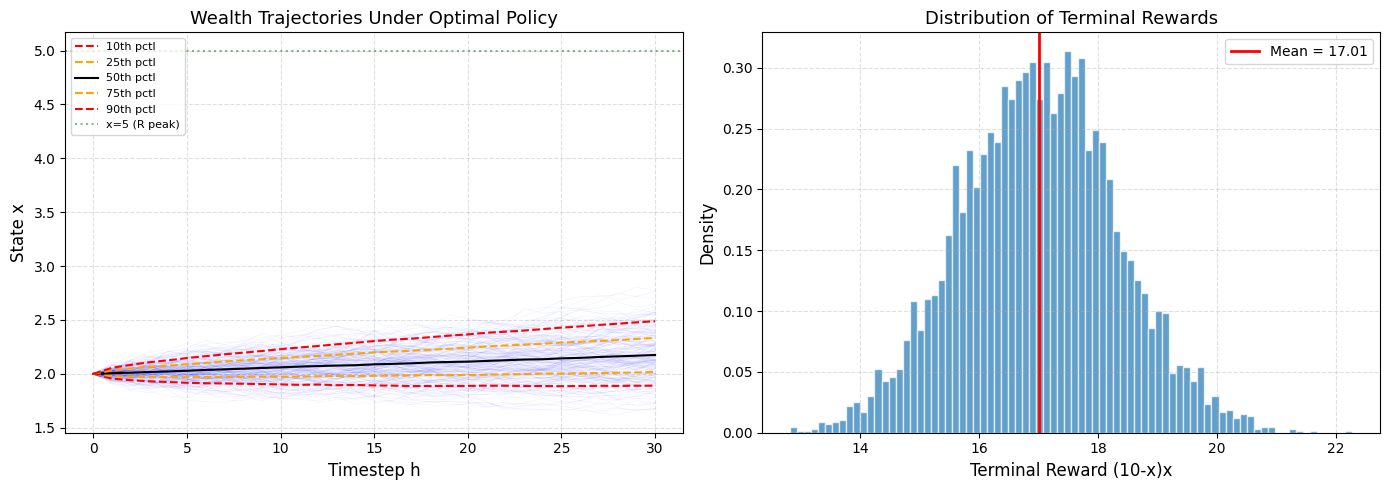


Running 15 RL iterations with K=2000 episodes...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running experiment...
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Experiment complete.


[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:  3.5min finished


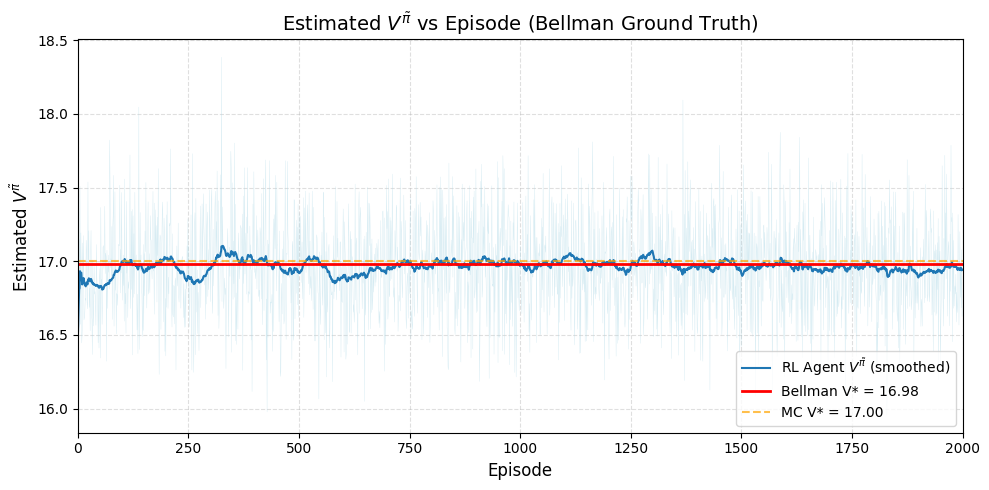

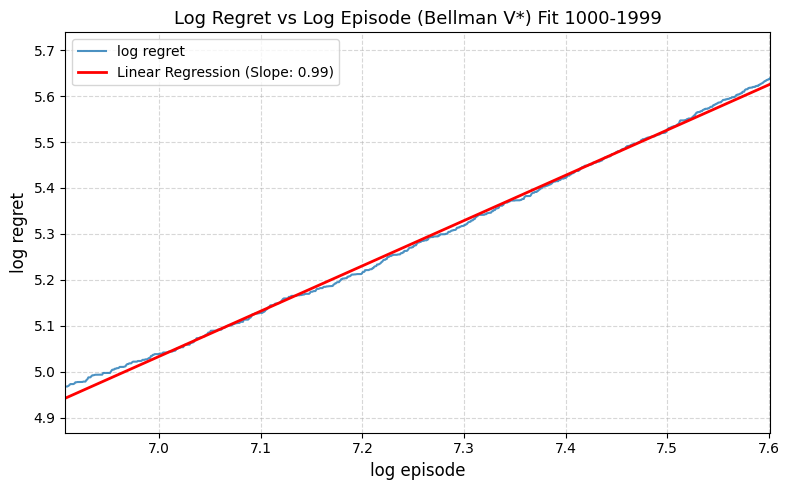


Regret slope = 0.9858, R² = 0.9982
Cumulative regret ~ K^0.99


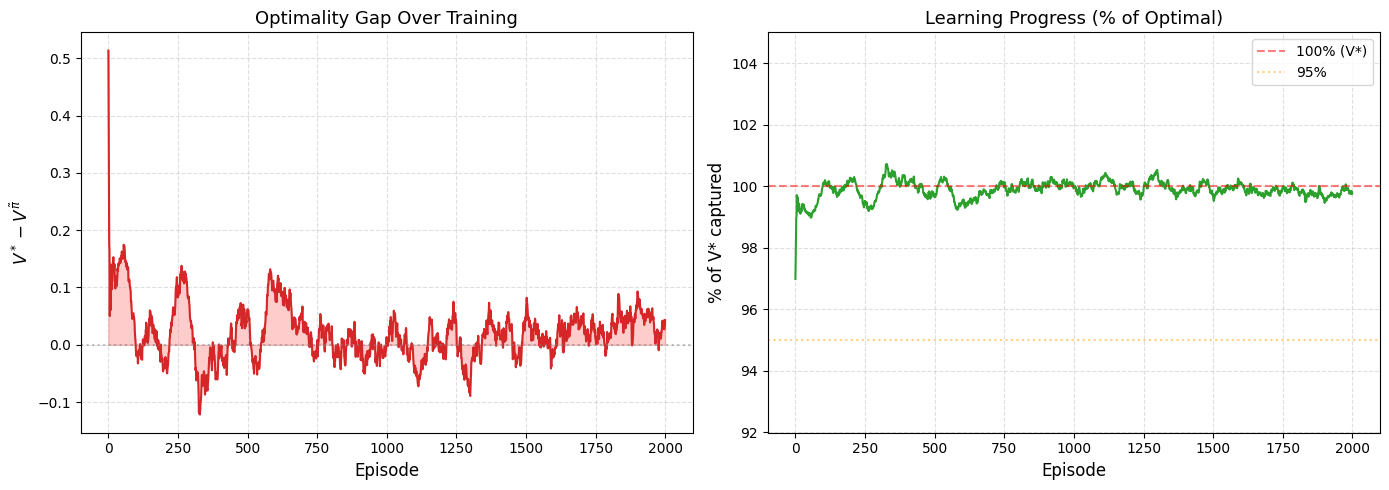


COMPLETE COMPARISON SUMMARY
  Bellman V*(x0=2):           16.9827
  MC Verification V*:         16.9996 ± 0.0042
  RL Final Avg (last 100):    16.9396 ± 0.3039
  Optimality Gap:             0.0430
  % of V* achieved:           99.7%
  Cumulative Regret:          281.0
  Regret Growth Order:        K^0.99
  Total Episodes (K):         2000
  Horizon (H):                30
  Parallel Runs:              15


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy import stats
import importlib

import aaro_draft as ad
from aaro_bellman import BellmanSolver

importlib.reload(ad)

# =============================================================================
# 1. SOLVE BELLMAN EQUATION
# =============================================================================
solver = BellmanSolver(
    theta=ad.theta,
    kappa=ad.kappa,
    sigma=ad.sigma,
    Delta=ad.Delta,
    rho=ad.rho,
    epLen=ad.epLen,
    action_dim=ad.action_dim,
    initial_q=ad.initial_q,
    n_state_grid=401,
    n_action_per_dim=21,
    n_quadrature=64
)

solver.solve(verbose=True)

v_star = solver.get_value(ad.starting_state, 0)
print(f"\nBellman V*(x0={ad.starting_state}) = {v_star:.6f}")

# Verify via simulation
v_sim, v_se, _ = solver.simulate_optimal_policy(ad.starting_state, n_sims=100000)
print(f"Simulated V*(x0) = {v_sim:.4f} ± {v_se:.4f}")

# =============================================================================
# 2. BELLMAN SOLVER ANALYSIS PLOTS
# =============================================================================
print("\nGenerating Bellman analysis plots...")

solver.plot_value_functions()
solver.plot_value_function_zoomed(x_range=(0, 6))
solver.plot_optimal_policy()
solver.plot_policy_heatmap()
solver.plot_trajectory_distribution(x0=ad.starting_state)

# =============================================================================
# 3. RUN THE RL AGENT
# =============================================================================
n_runs = 15

print(f"\nRunning {n_runs} RL iterations with K={ad.nEps} episodes...")

list_of_vpi = Parallel(n_jobs=-1, verbose=5)(
    delayed(ad.run_single_experiment_iteration)(i) for i in range(n_runs)
)

vpi_df = pd.DataFrame(list_of_vpi).T
vpi_estimate = vpi_df.mean(axis=1)

# =============================================================================
# 4. PLOT (a): V^π vs Episode with Bellman V* Line
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 5))
episodes = np.arange(len(vpi_estimate))

ax.plot(episodes, vpi_estimate,
        color='lightblue', linewidth=0.3, alpha=0.5)

window = 50
smoothed = vpi_estimate.rolling(window=window, min_periods=1).mean()
ax.plot(episodes, smoothed, color='tab:blue', linewidth=1.5,
        label=r'RL Agent $V^{\tilde{\pi}}$ (smoothed)')

ax.axhline(y=v_star, color='red', linewidth=2,
           label=f'Bellman V* = {v_star:.2f}')

# Also show MC V* for comparison
ax.axhline(y=v_sim, color='orange', linewidth=1.5, linestyle='--',
           label=f'MC V* = {v_sim:.2f}', alpha=0.7)

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel(r'Estimated $V^{\tilde{\pi}}$', fontsize=12)
ax.set_title(r'Estimated $V^{\tilde{\pi}}$ vs Episode (Bellman Ground Truth)',
             fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim([0, ad.nEps])
plt.tight_layout()
plt.show()

# =============================================================================
# 5. PLOT (b): Log Regret vs Log Episode (using exact Bellman V*)
# =============================================================================
instantaneous_regret = np.maximum(v_star - vpi_estimate.values, 0)
cumulative_regret = np.cumsum(instantaneous_regret)

episodes_1idx = np.arange(1, len(cumulative_regret) + 1)
valid_mask = cumulative_regret > 0
log_episodes = np.log(episodes_1idx[valid_mask])
log_regret = np.log(cumulative_regret[valid_mask])

fit_start = 1000
fit_end = ad.nEps
fit_mask = ((episodes_1idx[valid_mask] >= fit_start) &
            (episodes_1idx[valid_mask] <= fit_end))

if np.sum(fit_mask) > 10:
    log_eps_fit = log_episodes[fit_mask]
    log_reg_fit = log_regret[fit_mask]

    slope, intercept, r_value, _, _ = stats.linregress(
        log_eps_fit, log_reg_fit
    )
    fit_line = slope * log_eps_fit + intercept

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(log_episodes[fit_mask], log_regret[fit_mask],
            color='tab:blue', linewidth=1.5, alpha=0.8, label='log regret')
    ax.plot(log_eps_fit, fit_line, color='red', linewidth=2,
            label=f'Linear Regression (Slope: {slope:.2f})')

    ax.set_xlim([np.log(fit_start), np.log(fit_end)])
    y_pad = 0.15 * (log_reg_fit.max() - log_reg_fit.min())
    ax.set_ylim([log_reg_fit.min() - y_pad, log_reg_fit.max() + y_pad])

    ax.set_xlabel('log episode', fontsize=12)
    ax.set_ylabel('log regret', fontsize=12)
    ax.set_title(
        f'Log Regret vs Log Episode (Bellman V*) Fit {fit_start}-{fit_end-1}',
        fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print(f"\nRegret slope = {slope:.4f}, R² = {r_value**2:.4f}")
    print(f"Cumulative regret ~ K^{slope:.2f}")

# =============================================================================
# 6. CONVERGENCE GAP ANALYSIS
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: gap V* - V^π over time
ax = axes[0]
gap = v_star - smoothed
ax.plot(episodes, gap, color='tab:red', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax.fill_between(episodes, 0, gap, alpha=0.2, color='red')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel(r'$V^* - V^{\tilde{\pi}}$', fontsize=12)
ax.set_title('Optimality Gap Over Training', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.4)

# Right: % of V* captured
ax = axes[1]
pct_captured = (smoothed / v_star) * 100
ax.plot(episodes, pct_captured, color='tab:green', linewidth=1.5)
ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='100% (V*)')
ax.axhline(y=95, color='orange', linestyle=':', alpha=0.5, label='95%')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('% of V* captured', fontsize=12)
ax.set_title('Learning Progress (% of Optimal)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_ylim([max(0, pct_captured.min() - 5), 105])

plt.tight_layout()
plt.show()

# =============================================================================
# 7. SUMMARY TABLE
# =============================================================================
final_100_avg = vpi_estimate.iloc[-100:].mean()
final_100_std = vpi_estimate.iloc[-100:].std()

print("\n" + "=" * 65)
print("COMPLETE COMPARISON SUMMARY")
print("=" * 65)
print(f"  Bellman V*(x0=2):           {v_star:.4f}")
print(f"  MC Verification V*:         {v_sim:.4f} ± {v_se:.4f}")
print(f"  RL Final Avg (last 100):    {final_100_avg:.4f} ± {final_100_std:.4f}")
print(f"  Optimality Gap:             {v_star - final_100_avg:.4f}")
print(f"  % of V* achieved:           {100*final_100_avg/v_star:.1f}%")
print(f"  Cumulative Regret:          {cumulative_regret[-1]:.1f}")
if np.sum(fit_mask) > 10:
    print(f"  Regret Growth Order:        K^{slope:.2f}")
print(f"  Total Episodes (K):         {ad.nEps}")
print(f"  Horizon (H):                {ad.epLen}")
print(f"  Parallel Runs:              {n_runs}")
print("=" * 65)

BELLMAN SOLVER
  State grid:   401 points on [-15, 15]
  Action grid:  231 simplex points
  Quadrature:   64 Gauss-Hermite points
  Horizon:      30 steps
  Solving...
  h = 29 (terminal)... done
  h = 28... done
  h = 27... done
  h = 26... done
  h = 25... done
  h = 24... done
  h = 23... done
  h = 22... done
  h = 21... done
  h = 20... done
  h = 19... done
  h = 18... done
  h = 17... done
  h = 16... done
  h = 15... done
  h = 14... done
  h = 13... done
  h = 12... done
  h = 11... done
  h = 10... done
  h = 9... done
  h = 8... done
  h = 7... done
  h = 6... done
  h = 5... done
  h = 4... done
  h = 3... done
  h = 2... done
  h = 1... done
  h = 0... done

  V*(x0=2, h=0) = 24.894515

Bellman V*(x0=2) = 24.894515
Simulated V*(x0) = 24.9048 ± 0.0015

Generating Bellman analysis plots...


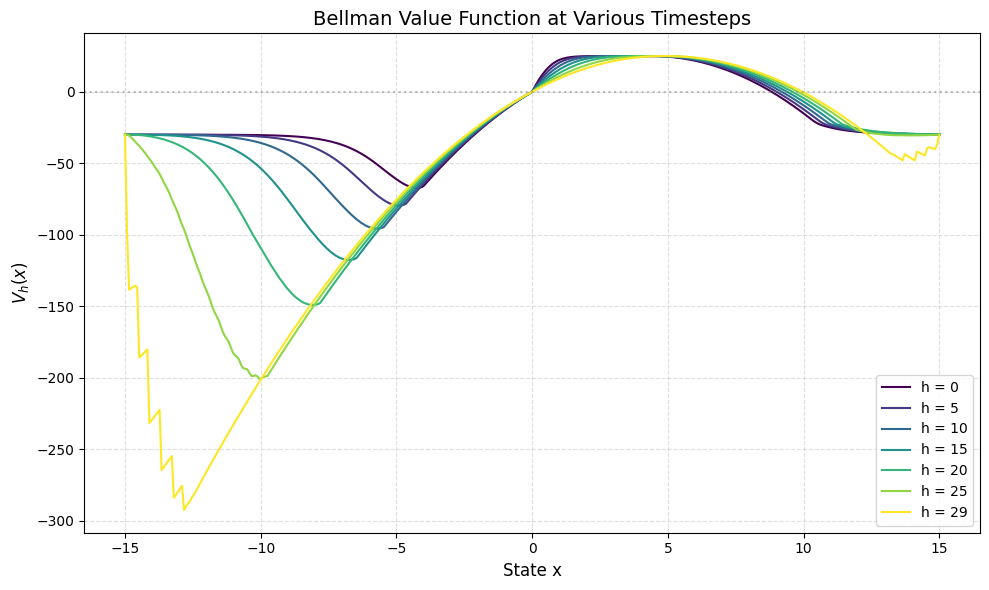

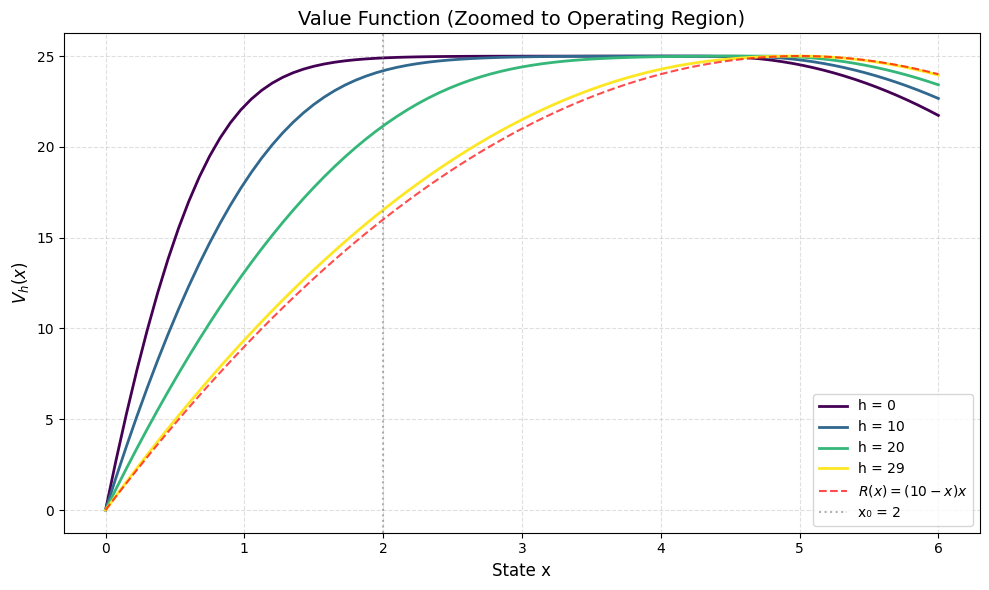

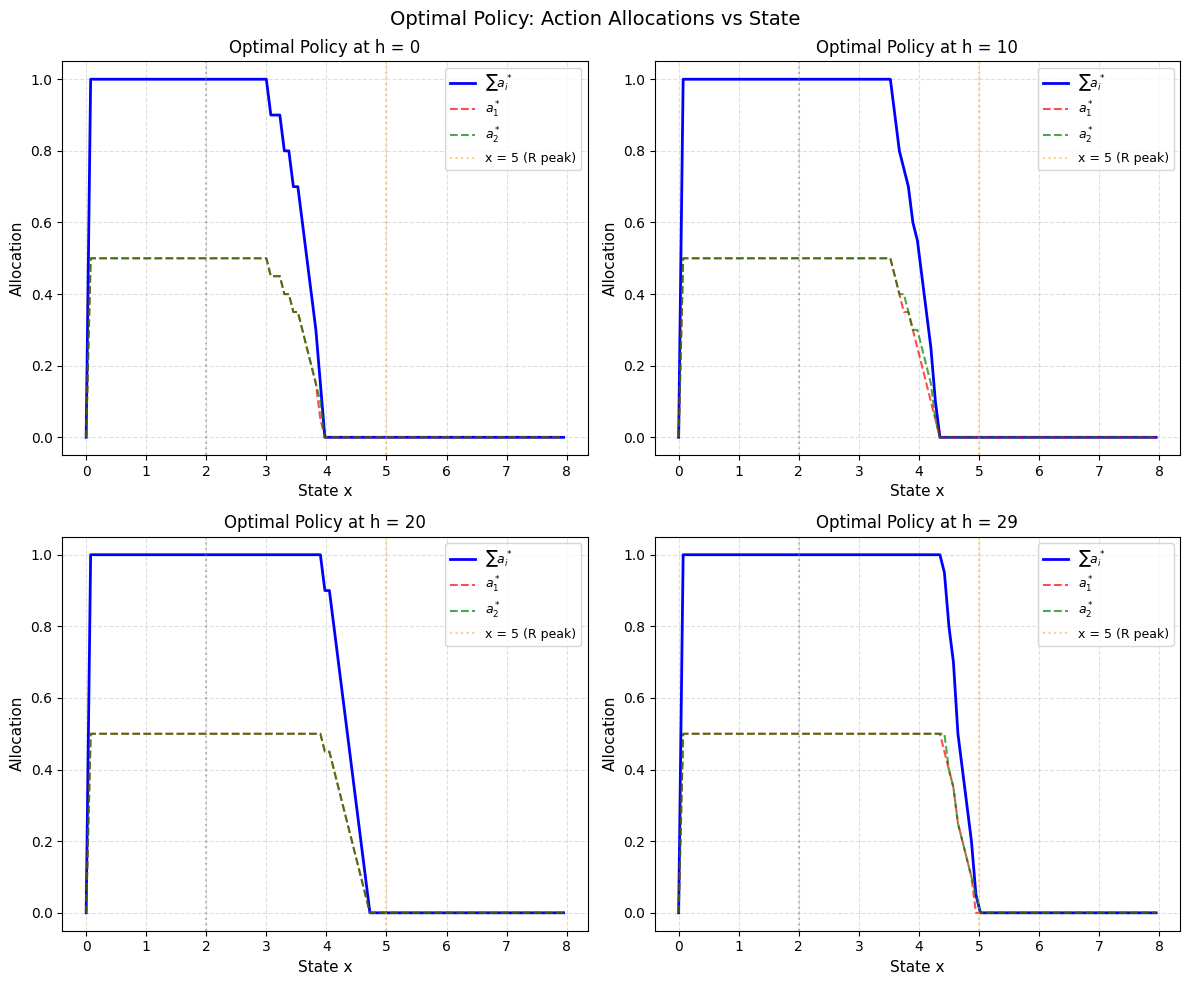

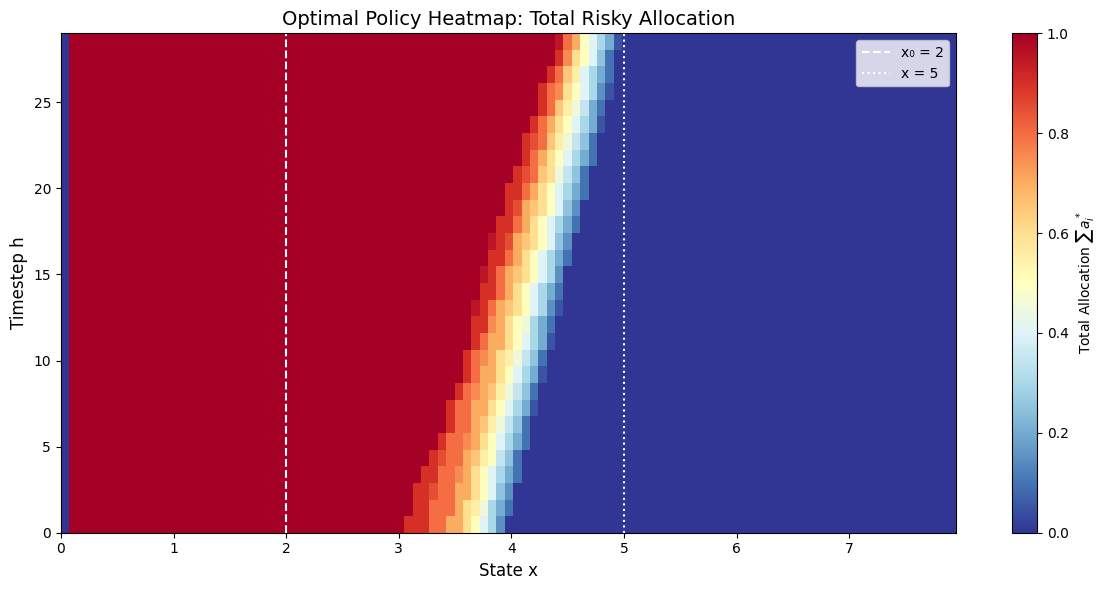

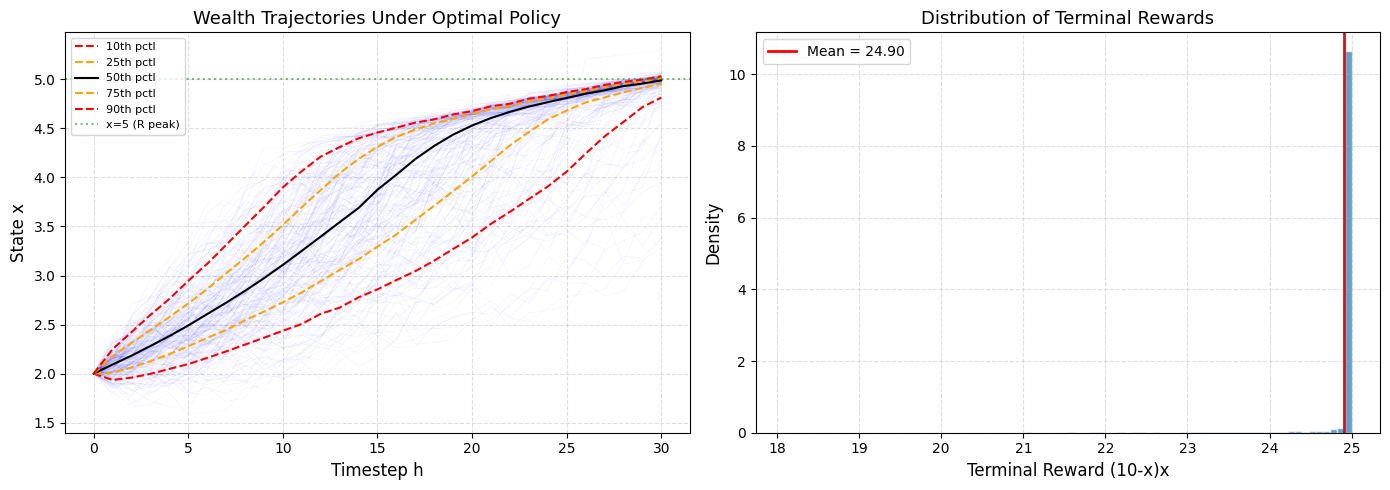


Running 15 RL iterations with K=2000 episodes...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running experiment...Running experiment...

Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Running experiment...
Experiment complete.
Experiment complete.


[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:  4.9min finished


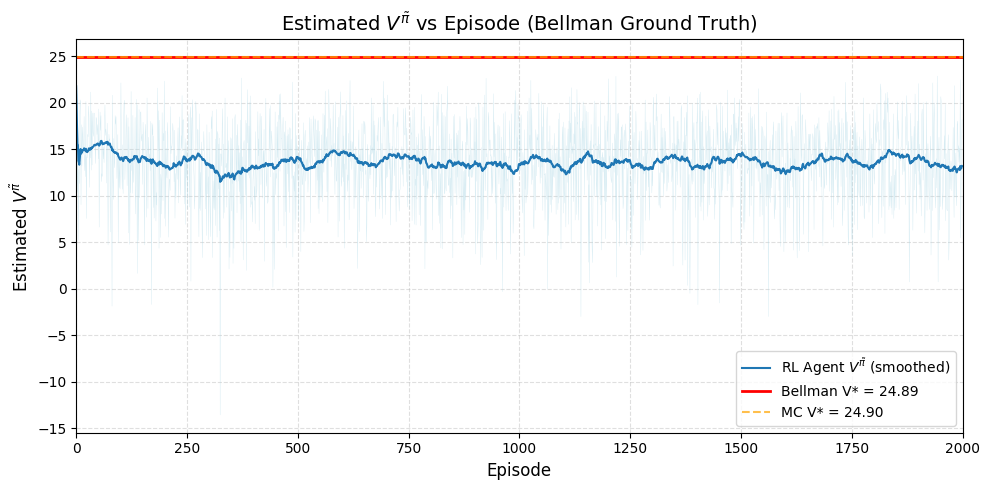

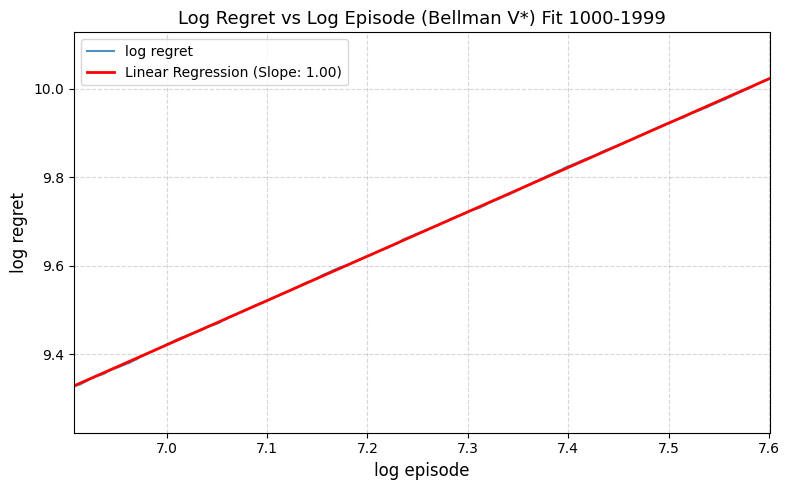


Regret slope = 1.0029, R² = 1.0000
Cumulative regret ~ K^1.00


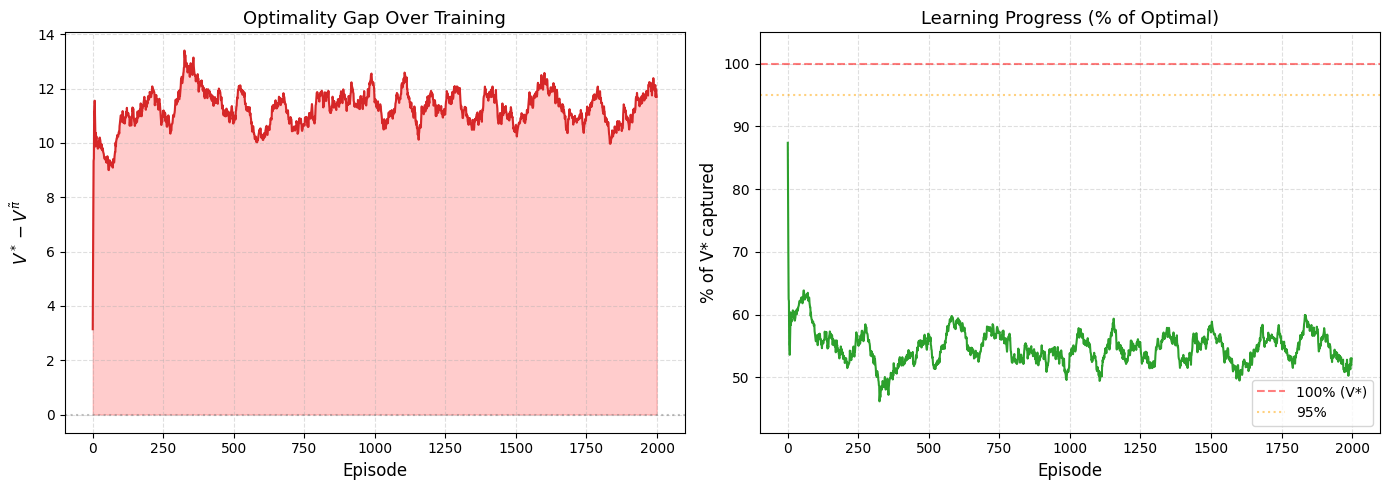


COMPLETE COMPARISON SUMMARY
  Bellman V*(x0=2):           24.8945
  MC Verification V*:         24.9048 ± 0.0015
  RL Final Avg (last 100):    13.1839 ± 4.5324
  Optimality Gap:             11.7106
  % of V* achieved:           53.0%
  Cumulative Regret:          22543.5
  Regret Growth Order:        K^1.00
  Total Episodes (K):         2000
  Horizon (H):                30
  Parallel Runs:              15


In [14]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy import stats
import importlib

import six_two_vol1_exp as sv
from aaro_bellman import BellmanSolver

importlib.reload(sv)

# =============================================================================
# 1. SOLVE BELLMAN EQUATION
# =============================================================================
solver = BellmanSolver(
    theta=sv.theta,
    kappa=sv.kappa,
    sigma=sv.sigma,
    Delta=sv.Delta,
    rho=sv.rho,
    epLen=sv.epLen,
    action_dim=sv.action_dim,
    initial_q=sv.initial_q,
    n_state_grid=401,
    n_action_per_dim=21,
    n_quadrature=64
)

solver.solve(verbose=True)

v_star = solver.get_value(sv.starting_state, 0)
print(f"\nBellman V*(x0={sv.starting_state}) = {v_star:.6f}")

# Verify via simulation
v_sim, v_se, _ = solver.simulate_optimal_policy(sv.starting_state, n_sims=100000)
print(f"Simulated V*(x0) = {v_sim:.4f} ± {v_se:.4f}")

# =============================================================================
# 2. BELLMAN SOLVER ANALYSIS PLOTS
# =============================================================================
print("\nGenerating Bellman analysis plots...")

solver.plot_value_functions()
solver.plot_value_function_zoomed(x_range=(0, 6))
solver.plot_optimal_policy()
solver.plot_policy_heatmap()
solver.plot_trajectory_distribution(x0=sv.starting_state)

# =============================================================================
# 3. RUN THE RL AGENT
# =============================================================================
n_runs = 15

print(f"\nRunning {n_runs} RL iterations with K={sv.nEps} episodes...")

list_of_vpi = Parallel(n_jobs=-1, verbose=5)(
    delayed(sv.run_single_experiment_iteration)(i) for i in range(n_runs)
)

vpi_df = pd.DataFrame(list_of_vpi).T
vpi_estimate = vpi_df.mean(axis=1)

# =============================================================================
# 4. PLOT (a): V^π vs Episode with Bellman V* Line
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 5))
episodes = np.arange(len(vpi_estimate))

ax.plot(episodes, vpi_estimate,
        color='lightblue', linewidth=0.3, alpha=0.5)

window = 50
smoothed = vpi_estimate.rolling(window=window, min_periods=1).mean()
ax.plot(episodes, smoothed, color='tab:blue', linewidth=1.5,
        label=r'RL Agent $V^{\tilde{\pi}}$ (smoothed)')

ax.axhline(y=v_star, color='red', linewidth=2,
           label=f'Bellman V* = {v_star:.2f}')

# Also show MC V* for comparison
ax.axhline(y=v_sim, color='orange', linewidth=1.5, linestyle='--',
           label=f'MC V* = {v_sim:.2f}', alpha=0.7)

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel(r'Estimated $V^{\tilde{\pi}}$', fontsize=12)
ax.set_title(r'Estimated $V^{\tilde{\pi}}$ vs Episode (Bellman Ground Truth)',
             fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim([0, sv.nEps])
plt.tight_layout()
plt.show()

# =============================================================================
# 5. PLOT (b): Log Regret vs Log Episode (using exact Bellman V*)
# =============================================================================
instantaneous_regret = np.maximum(v_star - vpi_estimate.values, 0)
cumulative_regret = np.cumsum(instantaneous_regret)

episodes_1idx = np.arange(1, len(cumulative_regret) + 1)
valid_mask = cumulative_regret > 0
log_episodes = np.log(episodes_1idx[valid_mask])
log_regret = np.log(cumulative_regret[valid_mask])

fit_start = 1000
fit_end = sv.nEps
fit_mask = ((episodes_1idx[valid_mask] >= fit_start) &
            (episodes_1idx[valid_mask] <= fit_end))

if np.sum(fit_mask) > 10:
    log_eps_fit = log_episodes[fit_mask]
    log_reg_fit = log_regret[fit_mask]

    slope, intercept, r_value, _, _ = stats.linregress(
        log_eps_fit, log_reg_fit
    )
    fit_line = slope * log_eps_fit + intercept

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(log_episodes[fit_mask], log_regret[fit_mask],
            color='tab:blue', linewidth=1.5, alpha=0.8, label='log regret')
    ax.plot(log_eps_fit, fit_line, color='red', linewidth=2,
            label=f'Linear Regression (Slope: {slope:.2f})')

    ax.set_xlim([np.log(fit_start), np.log(fit_end)])
    y_pad = 0.15 * (log_reg_fit.max() - log_reg_fit.min())
    ax.set_ylim([log_reg_fit.min() - y_pad, log_reg_fit.max() + y_pad])

    ax.set_xlabel('log episode', fontsize=12)
    ax.set_ylabel('log regret', fontsize=12)
    ax.set_title(
        f'Log Regret vs Log Episode (Bellman V*) Fit {fit_start}-{fit_end-1}',
        fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print(f"\nRegret slope = {slope:.4f}, R² = {r_value**2:.4f}")
    print(f"Cumulative regret ~ K^{slope:.2f}")

# =============================================================================
# 6. CONVERGENCE GAP ANALYSIS
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: gap V* - V^π over time
ax = axes[0]
gap = v_star - smoothed
ax.plot(episodes, gap, color='tab:red', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax.fill_between(episodes, 0, gap, alpha=0.2, color='red')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel(r'$V^* - V^{\tilde{\pi}}$', fontsize=12)
ax.set_title('Optimality Gap Over Training', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.4)

# Right: % of V* captured
ax = axes[1]
pct_captured = (smoothed / v_star) * 100
ax.plot(episodes, pct_captured, color='tab:green', linewidth=1.5)
ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='100% (V*)')
ax.axhline(y=95, color='orange', linestyle=':', alpha=0.5, label='95%')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('% of V* captured', fontsize=12)
ax.set_title('Learning Progress (% of Optimal)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_ylim([max(0, pct_captured.min() - 5), 105])

plt.tight_layout()
plt.show()

# =============================================================================
# 7. SUMMARY TABLE
# =============================================================================
final_100_avg = vpi_estimate.iloc[-100:].mean()
final_100_std = vpi_estimate.iloc[-100:].std()

print("\n" + "=" * 65)
print("COMPLETE COMPARISON SUMMARY")
print("=" * 65)
print(f"  Bellman V*(x0={sv.starting_state}):           {v_star:.4f}")
print(f"  MC Verification V*:         {v_sim:.4f} ± {v_se:.4f}")
print(f"  RL Final Avg (last 100):    {final_100_avg:.4f} ± {final_100_std:.4f}")
print(f"  Optimality Gap:             {v_star - final_100_avg:.4f}")
print(f"  % of V* achieved:           {100*final_100_avg/v_star:.1f}%")
print(f"  Cumulative Regret:          {cumulative_regret[-1]:.1f}")
if np.sum(fit_mask) > 10:
    print(f"  Regret Growth Order:        K^{slope:.2f}")
print(f"  Total Episodes (K):         {sv.nEps}")
print(f"  Horizon (H):                {sv.epLen}")
print(f"  Parallel Runs:              {n_runs}")
print("=" * 65)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy import stats
import importlib

Running Experiment 6.1: 50 parallel iterations, K=2000...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:   34.0s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  1.7min finished


V*(x0=4) = 474.8257


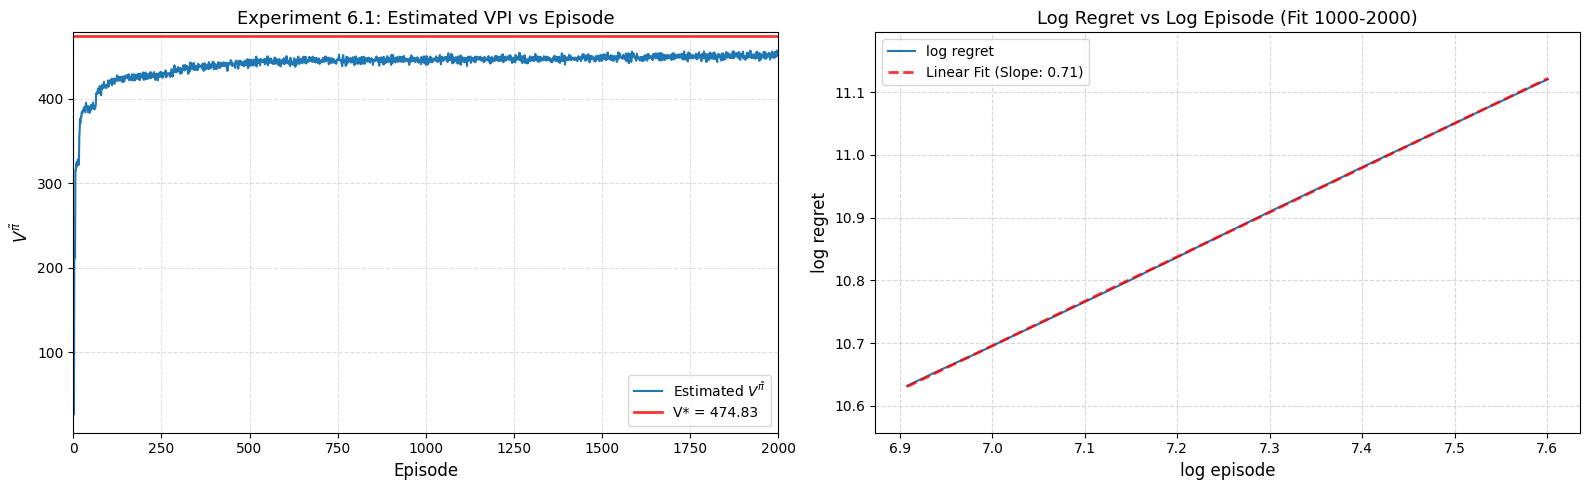


Exp 6.1 Summary:
  V* = 474.8257
  Regret slope = 0.71 (Sublinear if < 1, indicates convergence)

Training a single local agent to extract partition tree for Heat Map...


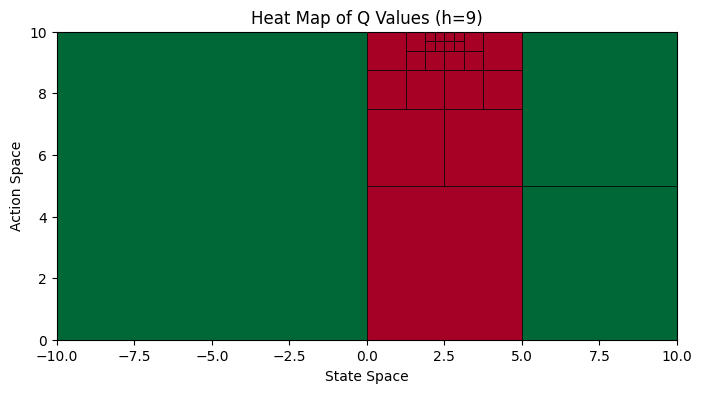

In [11]:
# =============================================================================
# EXPERIMENT 6.1: One-Dimensional Tractable Problem
# =============================================================================
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from joblib import Parallel, delayed
import importlib
import six_one_exp as so

importlib.reload(so)

# --- 1. Run the Experiments ---
n_runs_61 = 50
print(f"Running Experiment 6.1: {n_runs_61} parallel iterations, K={so.nEps}...")
list_of_vpi_61 = Parallel(n_jobs=-1, verbose=5)(
    delayed(so.run_single_experiment_iteration)(i) for i in range(n_runs_61)
)

vpi_df_61 = pd.DataFrame(list_of_vpi_61).T
vpi_estimate_61 = vpi_df_61.mean(axis=1)

# Compute True V* using the Bellman DP solver
optimal_value_61 = so.compute_optimal_value(so.starting_state, so.epLen, so.Delta)
print(f"V*(x0={so.starting_state}) = {optimal_value_61:.4f}")

# --- 2. Plot VPI and Regret ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: VPI vs Episode (No fading, just the solid mean line)
ax = axes[0]
episodes_61 = np.arange(len(vpi_estimate_61))
ax.plot(episodes_61, vpi_estimate_61, color='tab:blue', linewidth=1.5, label=r'Estimated $V^{\tilde{\pi}}$')
ax.axhline(y=optimal_value_61, color='red', linewidth=2, alpha=0.8, label=f'V* = {optimal_value_61:.2f}')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel(r'$V^{\tilde{\pi}}$', fontsize=12)
ax.set_title('Experiment 6.1: Estimated VPI vs Episode', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim([0, so.nEps])

# Plot 2: Log Regret
ax = axes[1]
regret_61 = np.maximum(optimal_value_61 - vpi_estimate_61.values, 0)
cum_regret_61 = np.cumsum(regret_61)
eps_1idx = np.arange(1, len(cum_regret_61) + 1)

valid = cum_regret_61 > 0
log_eps = np.log(eps_1idx[valid])
log_reg = np.log(cum_regret_61[valid])

# Fit on episodes 1000 to 2000
fit_mask = (eps_1idx[valid] >= 1000) & (eps_1idx[valid] <= so.nEps)
if np.sum(fit_mask) > 10:
    slope, intercept, _, _, _ = stats.linregress(log_eps[fit_mask], log_reg[fit_mask])
    ax.plot(log_eps[fit_mask], log_reg[fit_mask], color='tab:blue', linewidth=1.5, label='log regret')
    ax.plot(log_eps[fit_mask], slope * log_eps[fit_mask] + intercept, color='red', alpha=0.8, linewidth=2, linestyle='--', label=f'Linear Fit (Slope: {slope:.2f})')

    y_pad = 0.15 * (log_reg[fit_mask].max() - log_reg[fit_mask].min() + 0.01)
    ax.set_ylim([log_reg[fit_mask].min() - y_pad, log_reg[fit_mask].max() + y_pad])

ax.set_xlabel('log episode', fontsize=12)
ax.set_ylabel('log regret', fontsize=12)
ax.set_title(f'Log Regret vs Log Episode (Fit 1000-{so.nEps})', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nExp 6.1 Summary:")
print(f"  V* = {optimal_value_61:.4f}")
print(f"  Regret slope = {slope:.2f} (Sublinear if < 1, indicates convergence)")


# --- 3. Heat Map of Q Values Generation ---
print("\nTraining a single local agent to extract partition tree for Heat Map...")
env_map = so.make_diffMDP(so.epLen, so.starting_state)
agent_map = so.AdaptiveModelBasedDiscretization(so.epLen, so.nEps, so.scaling, so.split_threshold, False, True)

# Fast forward training loop
for ep in range(1, so.nEps + 1):
    env_map.reset()
    oldState = env_map.state
    agent_map.update_policy(ep)
    pContinue = 1
    h = 0
    while pContinue > 0 and h < so.epLen:
        action = agent_map.pick_action(oldState, h)
        reward, newState, pContinue = env_map.advance(action)
        agent_map.update_obs(oldState, action, reward, newState, h)
        oldState = newState
        h += 1

# Extract partitions for timestep 9
h_target = 9
leaves = agent_map.tree_list[h_target].tree_leaves

fig, ax = plt.subplots(figsize=(8, 4))
q_vals = [node.qVal for node in leaves]
min_q, max_q = min(q_vals), max(q_vals)

# RdYlGn uses Red for low, Yellow for middle, and Green for high
cmap = plt.cm.RdYlGn 

for node in leaves:
    # Ensure action_val is a float/scalar for plotting
    s_val = node.state_val
    a_val = node.action_val[0] if isinstance(node.action_val, np.ndarray) else node.action_val
    s_rad = node.radius
    a_rad = node.action_radius
    
    # Normalize Q for colourmap
    norm_q = (node.qVal - min_q) / (max_q - min_q + 1e-8)
    color = cmap(norm_q)
    
    # Draw partition boundaries
    rect = patches.Rectangle(
        (s_val - s_rad, a_val - a_rad),
        2 * s_rad, 2 * a_rad,
        linewidth=0.5, edgecolor='black', facecolor=color
    )
    ax.add_patch(rect)

ax.set_xlim(-10, 10)
ax.set_ylim(0, 10)
ax.set_xlabel("State Space")
ax.set_ylabel("Action Space")
ax.set_title(f"Heat Map of Q Values (h={h_target})")
plt.show()

Running Experiment 6.1: 50 parallel iterations, K=2000...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:   32.5s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  1.7min finished


V*(x0=4) = 474.8257


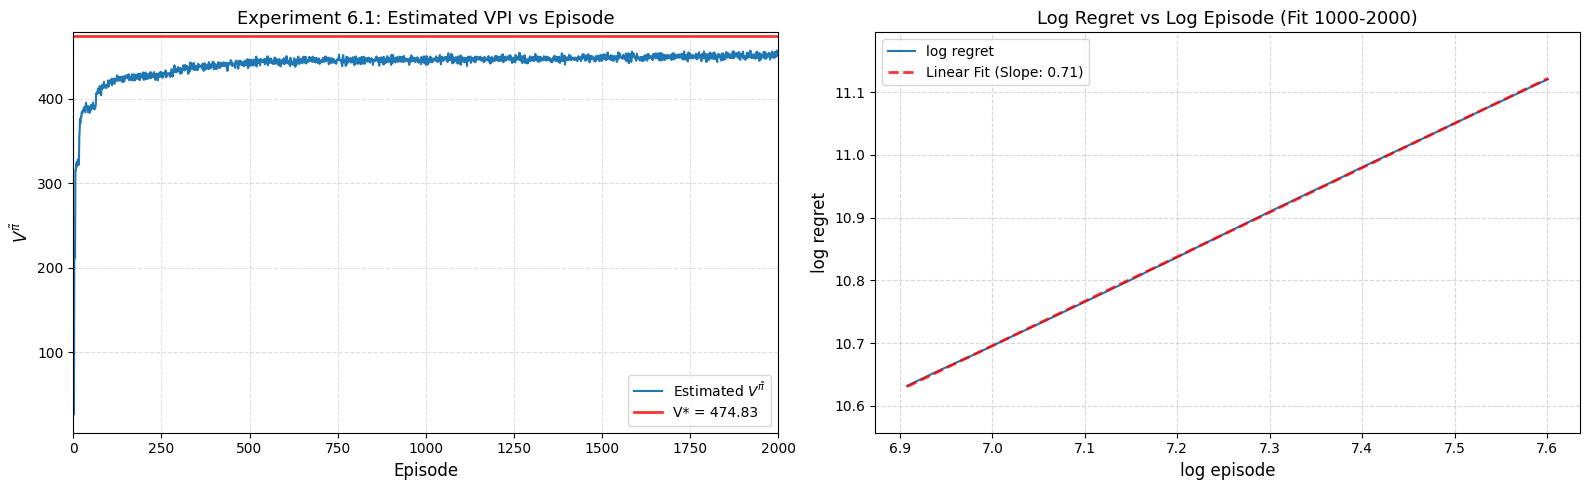


Exp 6.1 Summary:
  V* = 474.8257
  Regret slope = 0.71 (Sublinear if < 1, indicates convergence)

Training a single local agent to extract partition tree for Heat Map...


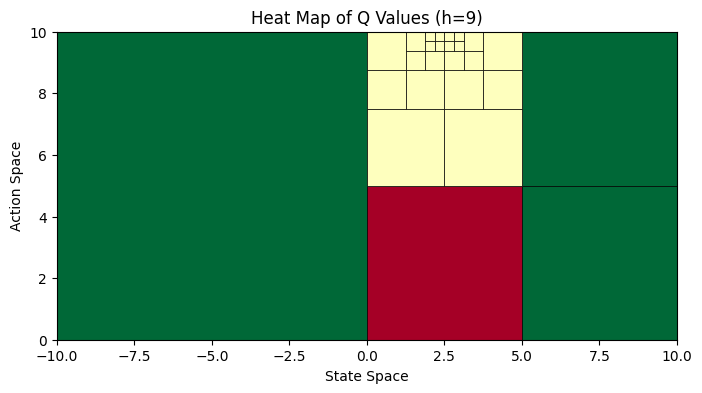

In [12]:
# =============================================================================
# EXPERIMENT 6.1: One-Dimensional Tractable Problem
# =============================================================================
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from scipy import stats
from joblib import Parallel, delayed
import importlib
import six_one_exp as so

importlib.reload(so)

# --- 1. Run the Experiments ---
n_runs_61 = 50
print(f"Running Experiment 6.1: {n_runs_61} parallel iterations, K={so.nEps}...")
list_of_vpi_61 = Parallel(n_jobs=-1, verbose=5)(
    delayed(so.run_single_experiment_iteration)(i) for i in range(n_runs_61)
)

vpi_df_61 = pd.DataFrame(list_of_vpi_61).T
vpi_estimate_61 = vpi_df_61.mean(axis=1)

# Compute True V* using the Bellman DP solver
optimal_value_61 = so.compute_optimal_value(so.starting_state, so.epLen, so.Delta)
print(f"V*(x0={so.starting_state}) = {optimal_value_61:.4f}")

# --- 2. Plot VPI and Regret ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: VPI vs Episode (Solid line only, no fading)
ax = axes[0]
episodes_61 = np.arange(len(vpi_estimate_61))
ax.plot(episodes_61, vpi_estimate_61, color='tab:blue', linewidth=1.5, label=r'Estimated $V^{\tilde{\pi}}$')
ax.axhline(y=optimal_value_61, color='red', linewidth=2, alpha=0.8, label=f'V* = {optimal_value_61:.2f}')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel(r'$V^{\tilde{\pi}}$', fontsize=12)
ax.set_title('Experiment 6.1: Estimated VPI vs Episode', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim([0, so.nEps])

# Plot 2: Log Regret
ax = axes[1]
regret_61 = np.maximum(optimal_value_61 - vpi_estimate_61.values, 0)
cum_regret_61 = np.cumsum(regret_61)
eps_1idx = np.arange(1, len(cum_regret_61) + 1)

valid = cum_regret_61 > 0
log_eps = np.log(eps_1idx[valid])
log_reg = np.log(cum_regret_61[valid])

# Fit on episodes 1000 to 2000
fit_mask = (eps_1idx[valid] >= 1000) & (eps_1idx[valid] <= so.nEps)
if np.sum(fit_mask) > 10:
    slope, intercept, _, _, _ = stats.linregress(log_eps[fit_mask], log_reg[fit_mask])
    ax.plot(log_eps[fit_mask], log_reg[fit_mask], color='tab:blue', linewidth=1.5, label='log regret')
    ax.plot(log_eps[fit_mask], slope * log_eps[fit_mask] + intercept, color='red', alpha=0.8, linewidth=2, linestyle='--', label=f'Linear Fit (Slope: {slope:.2f})')

    y_pad = 0.15 * (log_reg[fit_mask].max() - log_reg[fit_mask].min() + 0.01)
    ax.set_ylim([log_reg[fit_mask].min() - y_pad, log_reg[fit_mask].max() + y_pad])

ax.set_xlabel('log episode', fontsize=12)
ax.set_ylabel('log regret', fontsize=12)
ax.set_title(f'Log Regret vs Log Episode (Fit 1000-{so.nEps})', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nExp 6.1 Summary:")
print(f"  V* = {optimal_value_61:.4f}")
print(f"  Regret slope = {slope:.2f} (Sublinear if < 1, indicates convergence)")


# --- 3. Heat Map of Q Values Generation ---
print("\nTraining a single local agent to extract partition tree for Heat Map...")
env_map = so.make_diffMDP(so.epLen, so.starting_state)
agent_map = so.AdaptiveModelBasedDiscretization(so.epLen, so.nEps, so.scaling, so.split_threshold, False, True)

# Fast forward training loop
for ep in range(1, so.nEps + 1):
    env_map.reset()
    oldState = env_map.state
    agent_map.update_policy(ep)
    pContinue = 1
    h = 0
    while pContinue > 0 and h < so.epLen:
        action = agent_map.pick_action(oldState, h)
        reward, newState, pContinue = env_map.advance(action)
        agent_map.update_obs(oldState, action, reward, newState, h)
        oldState = newState
        h += 1

# Extract partitions for timestep 9
h_target = 9
leaves = agent_map.tree_list[h_target].tree_leaves

fig, ax = plt.subplots(figsize=(8, 4))
q_vals = [node.qVal for node in leaves]
min_q, max_q = min(q_vals), max(q_vals)

# Find a valid center for the colormap to force yellow to appear
center_q = np.median(q_vals)
if center_q <= min_q or center_q >= max_q:
    center_q = (min_q + max_q) / 2

# TwoSlopeNorm stretches the colors so the center_q is exactly the middle color (Yellow)
norm = mcolors.TwoSlopeNorm(vmin=min_q, vcenter=center_q, vmax=max_q)
cmap = plt.cm.RdYlGn 

for node in leaves:
    # Ensure action_val is a float/scalar for plotting
    s_val = node.state_val
    a_val = node.action_val[0] if isinstance(node.action_val, np.ndarray) else node.action_val
    s_rad = node.radius
    a_rad = node.action_radius
    
    # Get color via the normalized colormap
    color = cmap(norm(node.qVal))
    
    # Draw partition boundaries
    rect = patches.Rectangle(
        (s_val - s_rad, a_val - a_rad),
        2 * s_rad, 2 * a_rad,
        linewidth=0.5, edgecolor='black', facecolor=color
    )
    ax.add_patch(rect)

ax.set_xlim(-10, 10)
ax.set_ylim(0, 10)
ax.set_xlabel("State Space")
ax.set_ylabel("Action Space")
ax.set_title(f"Heat Map of Q Values (h={h_target})")
plt.show()